# Vineyard
Experimenting with weighted vineyard distance formulations. Longer line length -> consistent feature -> lower D. Low distance to the diagonal -> unimportant -> lower distance.

In [1]:
import sklearn
from sklearn.datasets import fetch_openml
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import plotly
import plotly.graph_objects as go


/var/folders/fg/n7d57ft153bf46npr6w6jjxr0000gn/T/ipykernel_12236/3356440145.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
import gudhi
import gudhi.wasserstein
import gudhi.hera
import ot

In [39]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

In [45]:
X = X.reshape((X.shape[0], 28, 28))

In [75]:
f, g = X[[np.where(y == x)[0][0] for x in "69"]]
# f, g = X[[np.random.choice(np.where(y == x)[0]) for x in "69"]]

In [14]:
g = np.ones_like(f)
for i in range(g.shape[0]):
    for j in range(g.shape[1]):
        g[i][j] = f[i-3][j] if i-1 >= 0 else 0

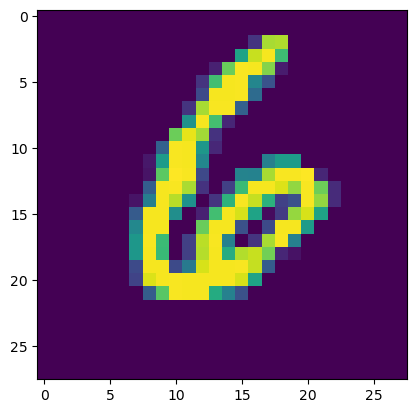

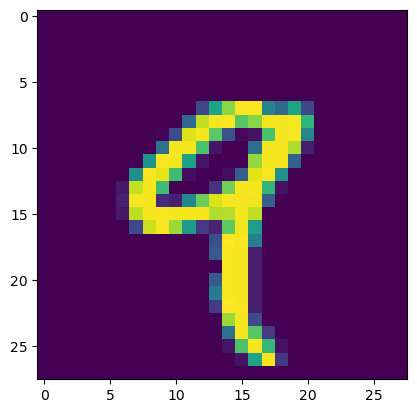

In [54]:
plt.imshow(f)
plt.show()
plt.imshow(g)

In [55]:
with open('h_end.npy', 'wb') as file:
    # fVAE = np.load(file)
    np.save(file, np.array([f,g]))

In [56]:
def persistence(array, dimension=None):
  height, width = array.shape
  cubeComplex = gudhi.CubicalComplex(
      dimensions = [width,height],
      top_dimensional_cells = 255 - array.flatten()
  )
 
  if dimension == None:
    persistence = cubeComplex.persistence()
  else:
    cubeComplex.compute_persistence()
    persistence = cubeComplex.persistence_intervals_in_dimension(dimension)
    
  return persistence

In [57]:
def stitch(PDs, ts):
    vines = [[0, None, [x,]] for x in range(len(PDs[0]))]
    ends = {x:x for x in range(len(PDs[0]))}
    
    for i in range(1, len(ts)):
        dist, match = gudhi.hera.wasserstein_distance(PDs[i-1], PDs[i], matching=True)
    
        baby = []
        # print("IIII", i)
    
        new_ends = {k:ends[k] for k in ends}
        for j, (x, y) in enumerate(match):
            # print(x,y)
            if x == -1:
                baby.append(j)
            elif y == -1: # end vines
                vines[ends[x]][1] = i
                vines[ends[x]][2].append(-1)
                # print(f"end {x} -> -1")
            else: # update vines
                vines[ends[x]][2].append(y)
                new_ends[y] = ends[x]
                # print(f"join {x} -> {y} (ind {ends[x]})")
        
        # new vines
        for j in baby:
            x, y = match[j]
            new_ends[y] = len(vines)
            vines.append([i, None, [y,]])
            # print(f"new {y} -> *")
    
        for k in [l for l in ends]: 
            if k >= len(PDs[i]):
                del new_ends[k]
    
        ends = new_ends

    return vines

In [58]:
def vineyard(ts, hs, verbose=False):
    PD0 = [persistence(h, dimension=1) for h in hs]
    vines = stitch(PD0, ts)

    poss = vines
    
    for i,_ in enumerate(vines):
        # print("II", i, vines[i])
        # print(i, vines[i][2], PD0[0][])
        repl = []
        for j,x in enumerate(vines[i][2]):
            if x == -1:
                # print(PD0[vines[i][0]+j-1][vines[i][2][j-1]], "xx")
                repl.append(np.mean(PD0[vines[i][0]+j-1][vines[i][2][j-1]])*np.ones((2,))) # proj prev
            else:
                repl.append(PD0[vines[i][0]+j][x])
    
        poss[i][2] = np.array(repl)

    res = [[[ts[p[0]+np.arange(len(p[2]))][i], *x] for i,x in enumerate(p[2])] for p in poss]
    mx = np.max([np.max(p[2]) for p in poss if np.inf not in p[2]])

    if verbose:
        gudhi.plot_persistence_diagram(persistence(hs[len(ts)-1]))
        plt.show()
        gudhi.plot_persistence_diagram(persistence(hs[0]))
        plt.show()
        
        gos = []
        
        for vine in res:
            vine = np.array(vine)
            # print(vine)
            gos.append(go.Scatter3d(x=vine[:,0], y=vine[:,1], z=vine[:,2], marker=dict(
                size=2,
            ),
            line=dict(
                width=2
            )))
        
        xs = np.linspace(0, mx, 10)
        zs = np.linspace(0, 1, 10)
        xss, zss = np.meshgrid(xs, zs)
        gos.append(go.Surface(x=zss, y=xss, z=xss, colorscale=[[0, '#333'], [1, '#333']], opacity=0.1, showscale=False)) # x - y = 0: diag plane
        
        fig = go.Figure(data=gos)
        
        fig.update_layout(
            width=800,
            height=700,
            scene=dict(
              xaxis_title='T (homotopy)',
              yaxis_title='Birth',
              zaxis_title='Death'
          )
        )
        
        fig.show()

    return res

Weighted integration:
$$v_{k}=g\left(\sum \ell(i)dt\right)\cdot \sum_{i=1}^{n}f\left(\Delta(\frac{p_i+p_{i-1}}{2})\right)\ell(i)dt$$
Here $\ell(i)=|p_i-p_{i-1}|$ and $\Delta()$ is the distance of the projection to the diagonal plane $\Delta$. This is for the $k$-th vine. Then,
$$V=\sum v_k$$

In [59]:
def vdist(vines, fD, fL): # diag weight func, length weight func
    V = 0
    for vine in vines:
        vine = np.array(vine)
    
        v, L = 0, 0
        for i in range(1, len(vine)):
            l = np.linalg.norm(vine[i][1:]-vine[i-1][1:])
            dt = vine[i][0] - vine[i-1][0]
    
            mid = np.mean([vine[i][1:],vine[i-1][1:]], axis=0)
            proj = np.mean(mid)*np.ones(2,)
            D = np.linalg.norm(proj-mid)
            
            v += fD(D)*l*dt
            L += l*dt
    
        v *= fL(L)
        V += v

    return V

In [60]:
fD = lambda D: 1
fL = lambda L: 1

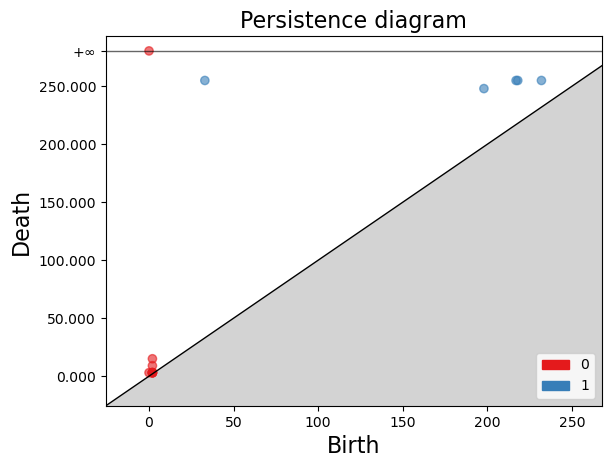

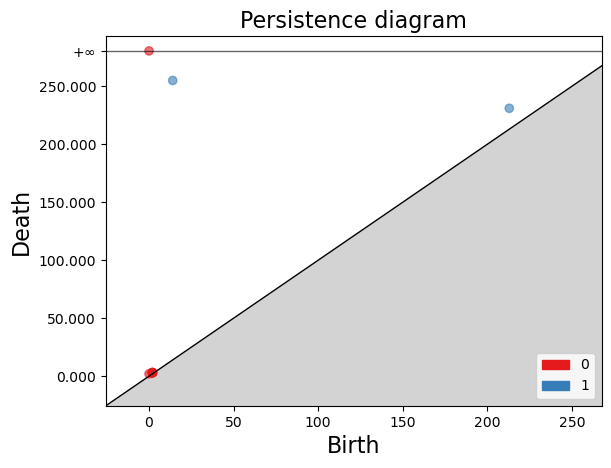

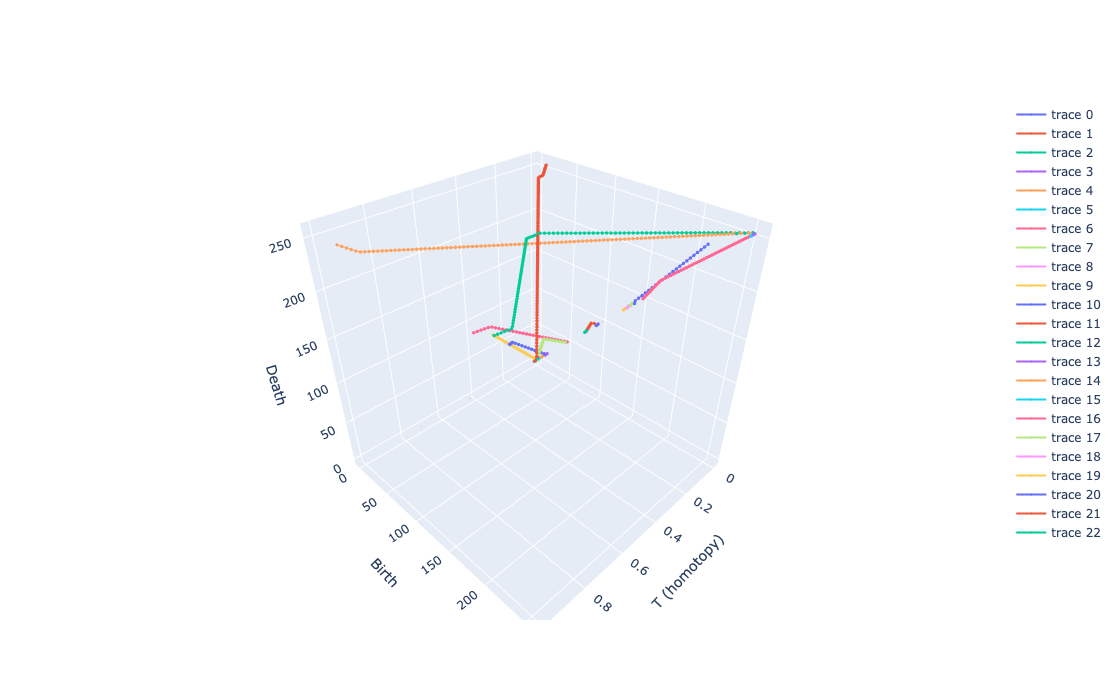

9.706917253357648

In [61]:
ts = np.linspace(0, 1, 100)
hs = np.array([t*f+(1-t)*g for t in ts]) 
vines = vineyard(ts, hs, verbose=True)
vdist(vines, fD, fL)

In [76]:
with open('hs69.npy', 'rb') as file:
    hsVAE = np.load(file)*255

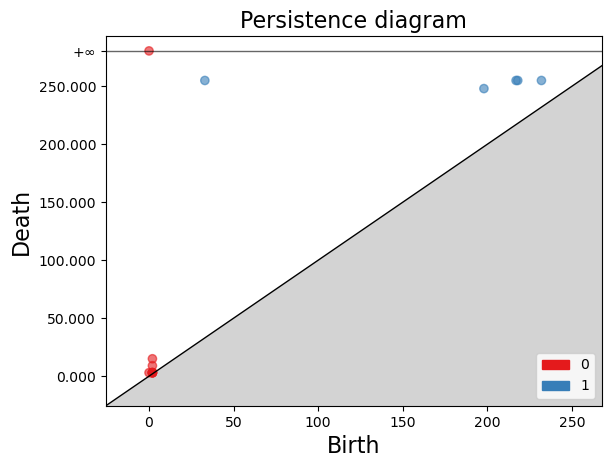

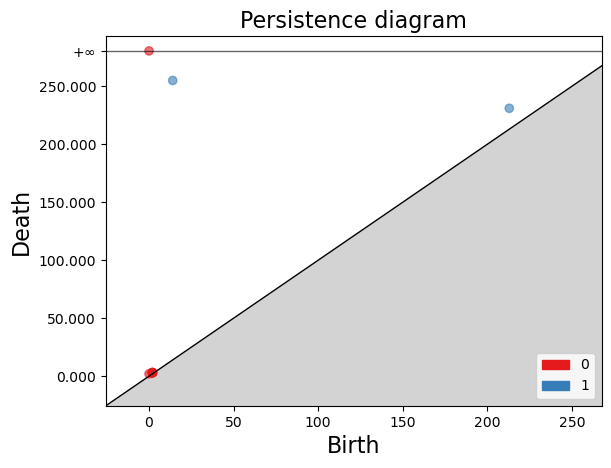

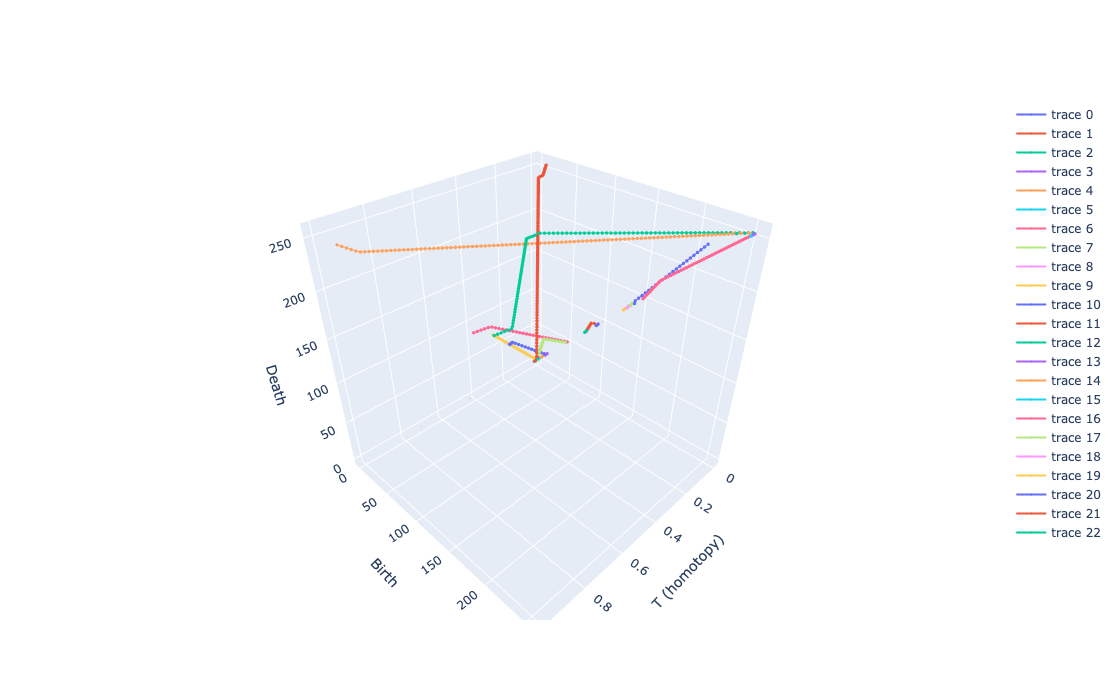

9.706917253357648

In [77]:
ts = np.linspace(0, 1, 100)
hs = np.array([t*f+(1-t)*g for t in ts]) 
vines = vineyard(ts, hs, verbose=True)
vdist(vines, fD, fL)

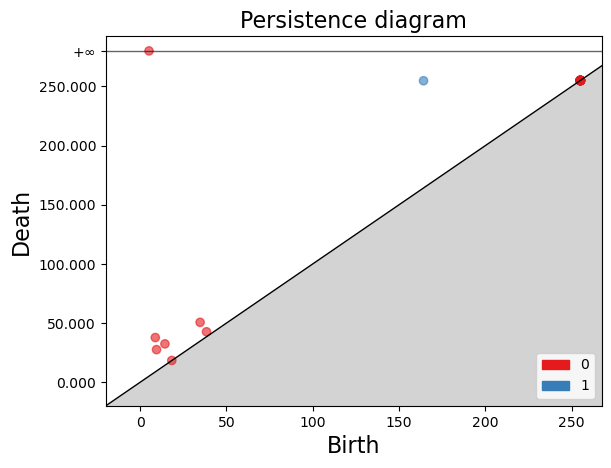

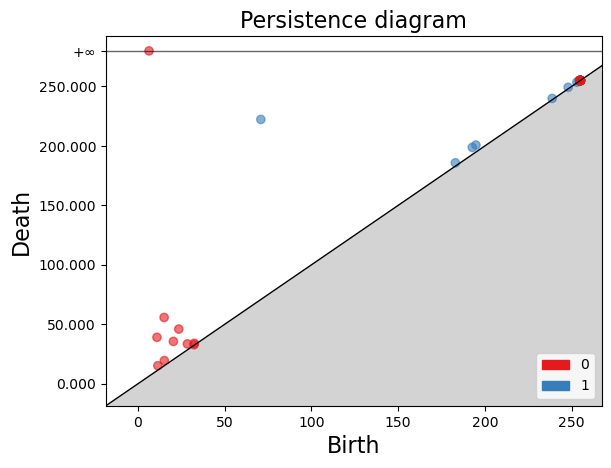

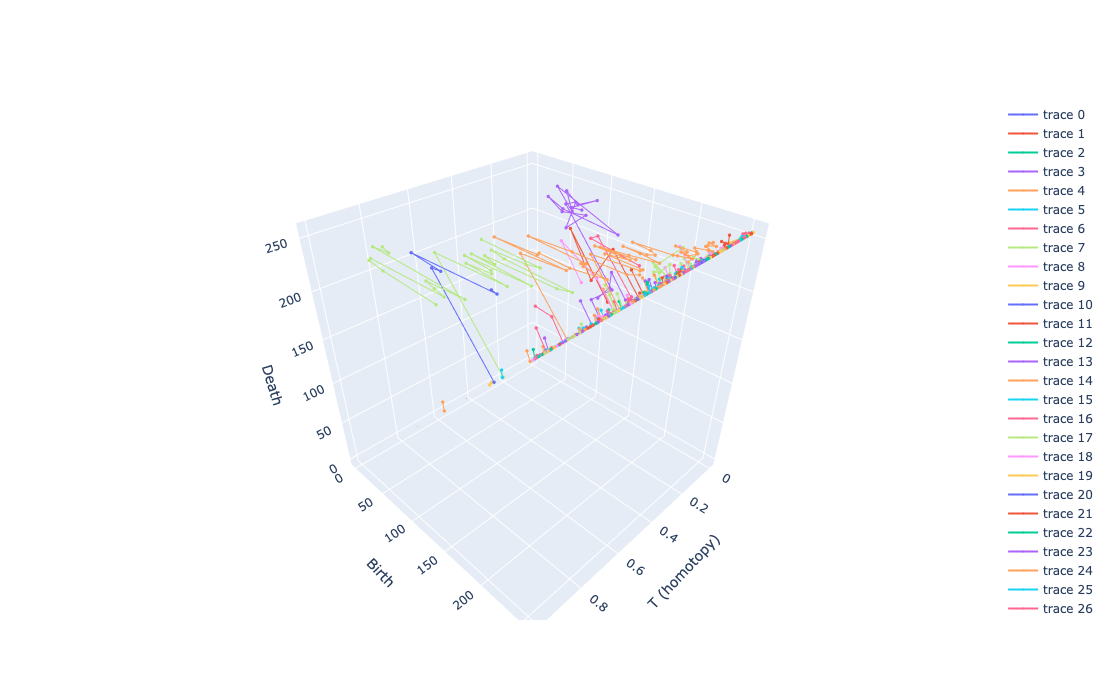

46.1981792553151

In [78]:
vines = vineyard(ts, hsVAE, verbose=True)
vdist(vines, fD, fL)